# SME Bankruptcy Model Showdown

**Question:** Can financial ratios identify Polish companies at risk of bankruptcy within one year?  
**User:** Anna Kowalska, a hypothetical financial-resilience adviser at a Polish regional SME-support agency.  
**Decision:** Which companies should be offered a confidential, voluntary financial-health consultation.  
**Positive class:** Bankruptcy (`1`).  
**Main metric:** Recall, because a false negative means missing an at-risk company. Precision and F1 are also reported because unnecessary outreach consumes capacity and can cause reputational harm.

This addresses **SDG 8 — Decent Work and Economic Growth** because business failure can threaten jobs, household income and local economic resilience. Statistics Poland reported 122 enterprise bankruptcies in the first quarter of 2023, 38.6% more than in the same quarter of 2022 ([source](https://stat.gov.pl/en/topics/economic-activities-finances/activity-of-enterprises-activity-of-companies/registrations-and-bankruptcies-of-enterprises-in-the-first-quarter-of-2023,21,18.html)).

The model supports outreach only. It must not make lending, pricing, procurement, collection or public-disclosure decisions.

## Step 1 — Import everything and prepare the experiment

This single setup step downloads the official UCI data, loads the one-year forecasting file, checks data quality, removes exact duplicates, creates an untouched stratified test set, defines leakage-safe pipelines and evaluates the majority-class baseline.

**Dataset:** [Polish Companies Bankruptcy, UCI](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data), CC BY 4.0. One row is a company financial statement, with 64 financial ratios and a later bankruptcy label. The data is historical and Polish, so results cannot automatically be transferred to current companies or other countries.

Raw data: 5,910 rows x 65 columns
Exact duplicates: 60
Total missing cells: 4666


,type,missing,unique
Attr1,float64,3,5622
Attr2,float64,3,5619
Attr3,float64,3,5653
Attr4,float64,21,5466
Attr5,float64,11,5778
...,...,...,...
Attr61,float64,15,5611
Attr62,float64,0,5559
Attr63,float64,21,5577
Attr64,float64,107,5548


,count,mean,std,min,25%,50%,75%,max
Attr1,5907.0,-0.022347,6.163655,-4.638900e+02,0.003965,0.04667,0.117050,87.459
Attr2,5907.0,0.465086,5.751283,-4.308700e+02,0.255355,0.45175,0.661635,72.416
Attr3,5907.0,0.189155,1.177729,-7.206700e+01,0.043953,0.21944,0.418430,28.336
Attr4,5889.0,4.892476,91.434574,-4.031100e-01,1.093700,1.65170,2.931000,6845.800
Attr5,5899.0,19.406758,21529.322027,-1.076400e+06,-43.836500,0.49149,48.765000,1250100.000
...,...,...,...,...,...,...,...,...
Attr61,5895.0,10.941497,41.166591,-9.249300e-02,4.278650,6.19890,9.350900,1308.500
Attr62,5910.0,241.978184,6221.135690,-2.365300e+02,44.646750,73.77850,118.720000,451380.000
Attr63,5889.0,9.127741,103.074304,-1.543200e+00,3.066900,4.93000,8.115800,7641.300
Attr64,5803.0,65.276716,2150.645860,-3.726500e+00,2.147500,4.09830,9.204200,158180.000


Removed duplicates: 60 | Removed constant columns: []


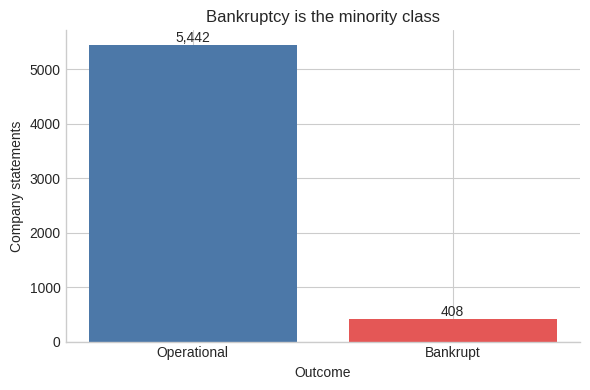

Train: 4,680 | Test: 1,170
Train bankruptcy rate: 6.97% | Test: 7.01%
Baseline CV recall: 0.000 ± 0.000

Setup complete. The test set has not been used for model selection.


In [1]:
# Imports and fixed settings
from pathlib import Path
from urllib.request import urlretrieve
import json, platform, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, balanced_accuracy_score, classification_report,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE, TEST_SIZE, N_SPLITS = 42, 0.20, 5
np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#4C78A8", "#E45756", "#59A14F", "#B279A2"]

# Download and extract the official UCI archive
DATA_URL = "https://archive.ics.uci.edu/static/public/365/polish+companies+bankruptcy+data.zip"
DATA_DIR, FIGURE_DIR = Path("data"), Path("figures")
DATA_DIR.mkdir(exist_ok=True); FIGURE_DIR.mkdir(exist_ok=True)
ZIP_PATH, EXTRACT_DIR = DATA_DIR / "polish_bankruptcy.zip", DATA_DIR / "polish_bankruptcy"
if not ZIP_PATH.exists(): urlretrieve(DATA_URL, ZIP_PATH)
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True)
    with zipfile.ZipFile(ZIP_PATH) as z: z.extractall(EXTRACT_DIR)
files = list(EXTRACT_DIR.rglob("5year.arff"))
assert len(files) == 1, f"Expected one 5year.arff file, found {files}"

# Load and decode
records, metadata = arff.loadarff(files[0])
df_raw = pd.DataFrame(records)
for col in df_raw.select_dtypes(include="object"):
    df_raw[col] = df_raw[col].map(lambda v: v.decode("utf-8") if isinstance(v, bytes) else v)
df_raw = df_raw.apply(pd.to_numeric, errors="coerce")
assert "class" in df_raw.columns
df_raw = df_raw.rename(columns={"class": "bankrupt"})
TARGET = "bankrupt"
assert set(df_raw[TARGET].dropna().unique()).issubset({0, 1})

# Explore before modelling
summary = pd.DataFrame({
    "type": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "unique": df_raw.nunique(dropna=True),
})
print(f"Raw data: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("Exact duplicates:", int(df_raw.duplicated().sum()))
print("Total missing cells:", int(df_raw.isna().sum().sum()))
display(summary)
display(df_raw.describe().T)

# Integrity corrections: no fitted statistics are used here
feature_cols = [x for x in df_raw.columns if x != TARGET]
df = df_raw.replace([np.inf, -np.inf], np.nan).drop_duplicates().copy()
constant_cols = [x for x in feature_cols if df[x].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols).reset_index(drop=True)
print("Removed duplicates:", len(df_raw) - len(df), "| Removed constant columns:", constant_cols)

# Class balance plot
balance = df[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Operational", "Bankrupt"], balance.values, color=COLORS[:2])
for bar, value in zip(bars, balance.values):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:,}", ha="center", va="bottom")
ax.set(title="Bankruptcy is the minority class", xlabel="Outcome", ylabel="Company statements")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# Untouched 20% test set
X, y = df.drop(columns=TARGET), df[TARGET].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Train bankruptcy rate: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

# Fitted preprocessing stays inside pipelines
scaled = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
unscaled = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"precision":"precision", "recall":"recall", "f1":"f1"}

# Required simple baseline
baseline = Pipeline([
    ("preprocessor", clone(scaled)),
    ("model", DummyClassifier(strategy="most_frequent"))
])
baseline_cv = cross_validate(
    baseline, X_train, y_train, cv=cv, scoring=SCORING,
    return_train_score=True, n_jobs=-1
)
baseline.fit(X_train, y_train)
print(f"Baseline CV recall: {baseline_cv['test_recall'].mean():.3f} ± {baseline_cv['test_recall'].std():.3f}")

print("\nSetup complete. The test set has not been used for model selection.")

## Step 2 — Tune and train KNN

KNN finds companies with similar financial ratios. Scaling is required because KNN calculates distances. `GridSearchCV` tests different neighbour counts, weighting rules and distance definitions using the training data only.

KNN best parameters: {'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform'}
KNN CV recall: 0.163 ± 0.043


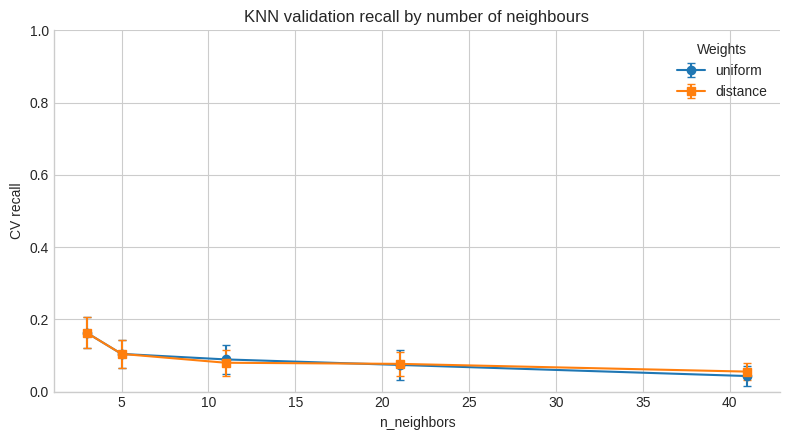

In [2]:
knn = Pipeline([
    ("preprocessor", clone(scaled)),
    ("model", KNeighborsClassifier())
])
knn_grid = {
    "model__n_neighbors": [3, 5, 11, 21, 41],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}
knn_search = GridSearchCV(
    knn, knn_grid, scoring="recall", cv=cv, n_jobs=-1,
    refit=True, return_train_score=True, error_score="raise"
)
knn_search.fit(X_train, y_train)
print("KNN best parameters:", knn_search.best_params_)
print(f"KNN CV recall: {knn_search.best_score_:.3f} ± "
      f"{knn_search.cv_results_['std_test_score'][knn_search.best_index_]:.3f}")

# Required score-versus-hyperparameter evidence
kr = pd.DataFrame(knn_search.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4.5))
for weights, marker in [("uniform", "o"), ("distance", "s")]:
    part = kr[(kr["param_model__weights"] == weights) & (kr["param_model__p"] == 2)].sort_values("param_model__n_neighbors")
    ax.errorbar(part["param_model__n_neighbors"].astype(int), part["mean_test_score"],
                yerr=part["std_test_score"], marker=marker, capsize=3, label=weights)
ax.set(title="KNN validation recall by number of neighbours", xlabel="n_neighbors", ylabel="CV recall", ylim=(0,1))
ax.legend(title="Weights"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Step 3 — Tune and train logistic regression

Logistic regression provides probabilities and a comparatively understandable linear model. `C` controls regularisation. Balanced class weights make errors on the minority bankruptcy class more influential.

In [3]:
logistic = Pipeline([
    ("preprocessor", clone(scaled)),
    ("model", LogisticRegression(max_iter=3000, solver="liblinear", random_state=RANDOM_STATE))
])
logistic_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "model__class_weight": [None, "balanced"],
}
logistic_search = GridSearchCV(
    logistic, logistic_grid, scoring="recall", cv=cv, n_jobs=-1,
    refit=True, return_train_score=True, error_score="raise"
)
logistic_search.fit(X_train, y_train)
print("Logistic best parameters:", logistic_search.best_params_)
print(f"Logistic CV recall: {logistic_search.best_score_:.3f} ± "
      f"{logistic_search.cv_results_['std_test_score'][logistic_search.best_index_]:.3f}")

Logistic best parameters: {'model__C': 100.0, 'model__class_weight': 'balanced'}
Logistic CV recall: 0.712 ± 0.031


## Step 4 — Tune and train random forest

Random forest is the third model. It can capture nonlinear relationships and feature interactions. Depth and leaf size control overfitting; class weights address imbalance. Trees need imputation but not scaling.

In [4]:
forest = Pipeline([
    ("preprocessor", clone(unscaled)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
])
forest_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 12],
    "model__min_samples_leaf": [1, 10],
    "model__class_weight": [None, "balanced"],
}
forest_search = GridSearchCV(
    forest, forest_grid, scoring="recall", cv=cv, n_jobs=-1,
    refit=True, return_train_score=True, error_score="raise"
)
forest_search.fit(X_train, y_train)
print("Forest best parameters:", forest_search.best_params_)
print(f"Forest CV recall: {forest_search.best_score_:.3f} ± "
      f"{forest_search.cv_results_['std_test_score'][forest_search.best_index_]:.3f}")

Forest best parameters: {'model__class_weight': 'balanced', 'model__max_depth': 12, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
Forest CV recall: 0.518 ± 0.045


## Step 5 — Check whether the models predict correctly

All choices are now fixed. This section evaluates the baseline and three tuned models once on the untouched test set. It reports training recall, cross-validation recall and spread, test precision, recall, F1 and balanced accuracy. The confusion matrices show correct predictions and both error types.

This also provides the visible evidence for **K1**: all three required scikit-learn classifiers are trained, tuned with multiple candidate settings and evaluated.

,model,trained,tuning_candidates,best_parameters,train_recall,cv_recall,test_precision,test_recall,test_f1,balanced_accuracy
0,Dummy baseline,True,1,{'strategy': 'most_frequent'},0.000,0.000 ± 0.000,0.000,0.000,0.000,0.500
1,KNN,True,20,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",0.368,0.163 ± 0.043,0.405,0.183,0.252,0.581
2,Logistic regression,True,10,"{'model__C': 100.0, 'model__class_weight': 'ba...",0.770,0.712 ± 0.031,0.223,0.744,0.343,0.774
3,Random forest,True,16,"{'model__class_weight': 'balanced', 'model__ma...",0.957,0.518 ± 0.045,0.480,0.573,0.522,0.763


K1 PASSED: KNN, logistic regression and random forest were trained, tuned and evaluated.


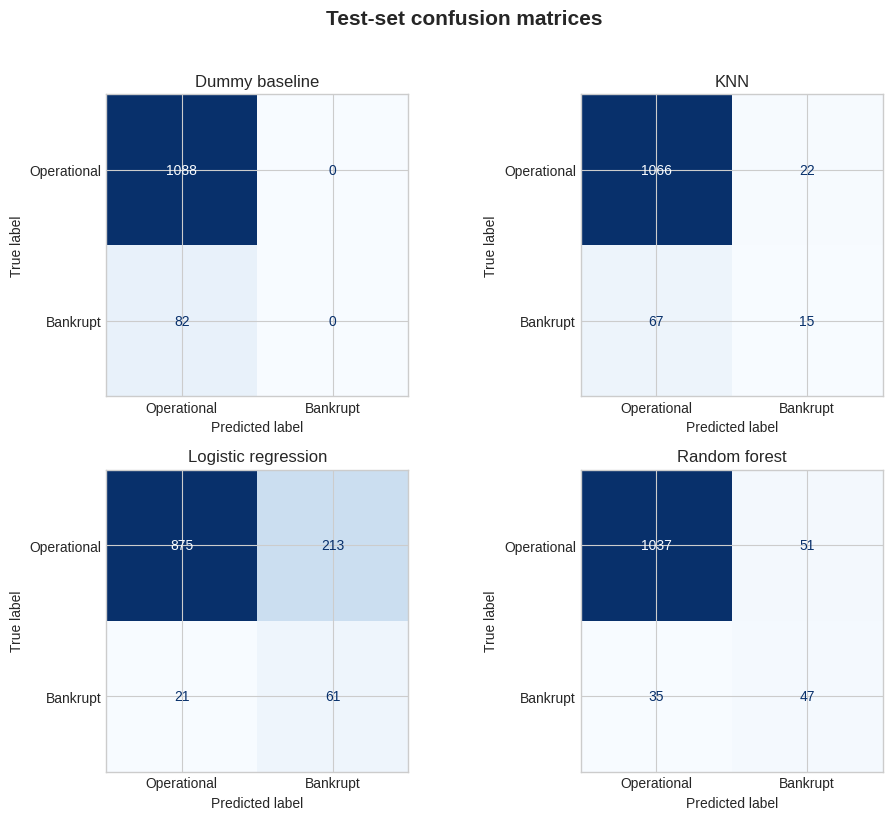

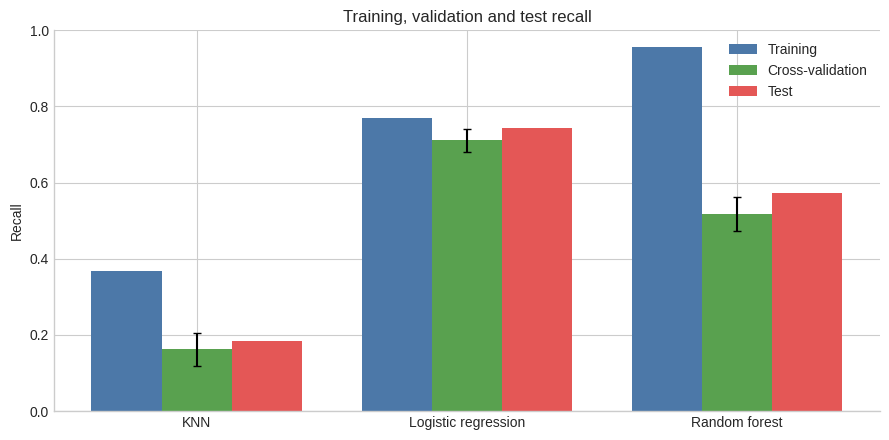


Dummy baseline
              precision    recall  f1-score   support

 Operational      0.930     1.000     0.964      1088
    Bankrupt      0.000     0.000     0.000        82

    accuracy                          0.930      1170
   macro avg      0.465     0.500     0.482      1170
weighted avg      0.865     0.930     0.896      1170


KNN
              precision    recall  f1-score   support

 Operational      0.941     0.980     0.960      1088
    Bankrupt      0.405     0.183     0.252        82

    accuracy                          0.924      1170
   macro avg      0.673     0.581     0.606      1170
weighted avg      0.903     0.924     0.910      1170


Logistic regression
              precision    recall  f1-score   support

 Operational      0.977     0.804     0.882      1088
    Bankrupt      0.223     0.744     0.343        82

    accuracy                          0.800      1170
   macro avg      0.600     0.774     0.612      1170
weighted avg      0.924     0.80

In [5]:
searches = {
    "KNN": knn_search,
    "Logistic regression": logistic_search,
    "Random forest": forest_search,
}
models = {
    "Dummy baseline": baseline,
    **{name: search.best_estimator_ for name, search in searches.items()}
}

rows, predictions, probabilities = [], {}, {}
for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    predictions[name] = test_pred
    probabilities[name] = model.predict_proba(X_test)[:, 1]

    if name == "Dummy baseline":
        cv_mean = baseline_cv["test_recall"].mean()
        cv_std = baseline_cv["test_recall"].std()
        params = {"strategy": "most_frequent"}
        candidates = 1
    else:
        search = searches[name]; i = search.best_index_
        cv_mean = search.cv_results_["mean_test_score"][i]
        cv_std = search.cv_results_["std_test_score"][i]
        params = search.best_params_
        candidates = len(search.cv_results_["params"])

    rows.append({
        "model": name,
        "trained": True,
        "tuning_candidates": candidates,
        "best_parameters": params,
        "train_recall": recall_score(y_train, train_pred, zero_division=0),
        "cv_recall_mean": cv_mean,
        "cv_recall_std": cv_std,
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
    })

results = pd.DataFrame(rows)
results["cv_recall"] = results.apply(lambda r: f"{r.cv_recall_mean:.3f} ± {r.cv_recall_std:.3f}", axis=1)
display(results[["model","trained","tuning_candidates","best_parameters","train_recall",
                 "cv_recall","test_precision","test_recall","test_f1","balanced_accuracy"]].round(3))

# K1 automated checks
required = {"KNN", "Logistic regression", "Random forest"}
assert required.issubset(set(results["model"]))
assert results[results["model"].isin(required)]["trained"].all()
assert (results[results["model"].isin(required)]["tuning_candidates"] > 1).all()
print("K1 PASSED: KNN, logistic regression and random forest were trained, tuned and evaluated.")

# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, pred) in zip(axes.ravel(), predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=["Operational", "Bankrupt"],
        cmap="Blues", colorbar=False, ax=ax
    )
    ax.set_title(name)
plt.suptitle("Test-set confusion matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

# Training, CV and test recall comparison
plot_rows = results[results["model"] != "Dummy baseline"]
x = np.arange(len(plot_rows)); width = 0.26
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x-width, plot_rows["train_recall"], width, label="Training", color=COLORS[0])
ax.bar(x, plot_rows["cv_recall_mean"], width, yerr=plot_rows["cv_recall_std"],
       capsize=3, label="Cross-validation", color=COLORS[2])
ax.bar(x+width, plot_rows["test_recall"], width, label="Test", color=COLORS[1])
ax.set_xticks(x, plot_rows["model"]); ax.set_ylim(0,1); ax.set_ylabel("Recall")
ax.set_title("Training, validation and test recall")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# Error analysis table for every model
for name, pred in predictions.items():
    print(f"\n{name}")
    print(classification_report(y_test, pred, target_names=["Operational", "Bankrupt"],
                                digits=3, zero_division=0))

results.assign(best_parameters=results["best_parameters"].map(json.dumps)).to_csv(
    "model_comparison.csv", index=False
)

## Step 6 — Choose the winner and use it

The winner is selected from cross-validation, not by repeatedly checking the test set. Logistic regression is preferred when it is within one validation standard deviation of the highest score because it is easier to audit. Otherwise, the highest-CV-recall model wins.

The code then checks errors, compares recall across company-size groups and makes one prediction for a fictional company. A large test drop or serious subgroup gap can still justify recommending **none of the models** for deployment.

In [6]:
# Select using CV evidence only
real_results = results[results["model"] != "Dummy baseline"].copy()
best_cv = real_results.loc[real_results["cv_recall_mean"].idxmax()]
log_cv = real_results[real_results["model"] == "Logistic regression"].iloc[0]

if log_cv["cv_recall_mean"] >= best_cv["cv_recall_mean"] - best_cv["cv_recall_std"]:
    winner_name = "Logistic regression"
    reason = "It is within one CV standard deviation of the top score and is easier to audit."
else:
    winner_name = best_cv["model"]
    reason = "It has a CV recall advantage larger than the chosen uncertainty margin."

winner = models[winner_name]
winner_pred = predictions[winner_name]
winner_row = results[results["model"] == winner_name].iloc[0]

print("WINNER:", winner_name)
print("Reason:", reason)
print(f"CV recall: {winner_row.cv_recall_mean:.3f} ± {winner_row.cv_recall_std:.3f}")
print(f"Test precision: {winner_row.test_precision:.3f}")
print(f"Test recall: {winner_row.test_recall:.3f}")
print(f"Test F1: {winner_row.test_f1:.3f}")

# Analyse false negatives and false positives
errors = X_test.copy()
errors["actual"] = y_test.to_numpy()
errors["predicted"] = winner_pred
errors["error_type"] = np.select(
    [(errors.actual == 1) & (errors.predicted == 0),
     (errors.actual == 0) & (errors.predicted == 1)],
    ["false_negative", "false_positive"], default="correct"
)
display(errors["error_type"].value_counts().rename("count"))

# Group check: Attr29 is documented as log(total assets), used only as a size proxy
_, bins = pd.qcut(X_train["Attr29"].dropna(), q=3, retbins=True, duplicates="drop")
bins[0], bins[-1] = -np.inf, np.inf
groups = pd.DataFrame({"Attr29":X_test["Attr29"], "actual":y_test, "predicted":winner_pred})
groups["size_group"] = pd.cut(groups["Attr29"], bins=bins, include_lowest=True).astype(str)
groups.loc[groups["Attr29"].isna(), "size_group"] = "Missing"

group_rows = []
for group, part in groups.groupby("size_group"):
    group_rows.append({
        "size_group":group, "n":len(part), "bankruptcies":int(part.actual.sum()),
        "precision":precision_score(part.actual, part.predicted, zero_division=0),
        "recall":recall_score(part.actual, part.predicted, zero_division=0),
        "f1":f1_score(part.actual, part.predicted, zero_division=0)
    })
group_metrics = pd.DataFrame(group_rows)
display(group_metrics.round(3))

# New fictional company: median training profile with several altered ratios
new_company = pd.DataFrame([X_train.median(numeric_only=True)]).reindex(columns=X_train.columns)
for feature, multiplier in {"Attr1":0.60, "Attr2":1.20, "Attr4":0.75, "Attr6":0.70}.items():
    if feature in new_company: new_company.loc[0, feature] *= multiplier
new_class = int(winner.predict(new_company)[0])
new_probability = float(winner.predict_proba(new_company)[0, 1])
print("\nFICTIONAL COMPANY")
print("Prediction:", "Bankruptcy risk" if new_class == 1 else "No bankruptcy flag")
print(f"Estimated probability: {new_probability:.1%}")
print("Action:", "Consider voluntary outreach" if new_class == 1 else "No model-based outreach flag")

WINNER: Logistic regression
Reason: It is within one CV standard deviation of the top score and is easier to audit.
CV recall: 0.712 ± 0.031
Test precision: 0.223
Test recall: 0.744
Test F1: 0.343


,count
error_type,
correct,936
false_positive,213
false_negative,21


,size_group,n,bankruptcies,precision,recall,f1
0,"(-inf, 3.852]",397,40,0.201,0.850,0.325
1,"(3.852, 4.469]",378,23,0.257,0.783,0.387
2,"(4.469, inf]",394,19,0.257,0.474,0.333
3,Missing,1,0,0.000,0.000,0.000



FICTIONAL COMPANY
Prediction: No bankruptcy flag
Estimated probability: 38.0%
Action: No model-based outreach flag


## Final conclusion and ethical reflection

After running the notebook, add a short paragraph using the actual numbers printed in Steps 5 and 6. State whether the winner clearly beat the baseline, whether test recall was close to cross-validation recall, how many bankruptcies it missed, how many false alerts it produced and whether results differed by company size.

The model affects owners, employees, suppliers and households even though the records concern companies. False negatives can mean missed assistance; false positives can cause anxiety and reputational harm. Predictions must remain confidential. The dataset lacks region, ownership demographics and complete industry information, so fairness for those groups cannot be established. Historical Polish results cannot automatically generalise to current or non-Polish companies. Any real pilot needs current representative data, legal review, human oversight and ongoing monitoring.

## Rubric coverage

| Criterion | Evidence in this notebook |
|---|---|
| **K1 — AI tool** | Steps 2–5 train, tune and evaluate KNN, logistic regression and random forest with scikit-learn; Step 5 produces an automated K1 evidence check. |
| **K2 — SDG relevance** | Bankruptcy is connected to jobs, income security and local economic resilience under SDG 8. |
| **K3 — Scope** | A named SME adviser uses the output for a specific voluntary-outreach decision. |
| **1 — Problem definition** | Outcome, population, location, one-year horizon, scale evidence and sources are stated. |
| **2 — User group** | The user, affected stakeholders, intended use and prohibited users/uses are described. |
| **3 — Solution description** | Step 1 moves from raw data through integrity checks, split and pipelines; Steps 2–6 cover tuning, evaluation and output. |
| **4 — Problem–solution fit** | Recall reflects missed-support costs; precision captures unnecessary outreach; the dummy baseline tests whether ML adds value. |
| **5 — Working prototype** | Restart and Run All produces the comparison, winner, error analysis and a fictional-company prediction without manual data edits. |
| **6 — Ethical reasoning** | Reputational harm, punitive reuse, subgroup differences, missing groups, transfer risk and mitigations are documented. |

### Before submission

1. Restart the Colab runtime and select **Run all**.
2. Confirm all six steps finish without errors.
3. Replace the first paragraph of this final section with your actual interpretation.
4. Save the notebook with outputs visible.
5. Add a README containing the dataset card, final comparison table, recommendation and run instructions.
6. Commit the notebook, README and permitted data files to GitHub.